In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

BOLD = '\033[1m'
END = '\033[0m'

# Data

In [3]:
# Import Data
loan_df = pd.read_csv("./Loan_Data.csv")
loan_df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [4]:
# Data Check
print(f"\nSHAPE: {loan_df.shape}")

print("\nDATA TYPE:") 
print(loan_df.dtypes)

print("\nNULL DATA:") 
print(loan_df.isnull().sum())

print("\nDEFAULT DIST:")
print(loan_df['default'].value_counts(normalize=True))


SHAPE: (10000, 8)

DATA TYPE:
customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

NULL DATA:
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

DEFAULT DIST:
default
0    0.8149
1    0.1851
Name: proportion, dtype: float64


In [5]:
loan_df = loan_df.drop('customer_id', axis = 1)
loan_df.columns

Index(['credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

# EDA

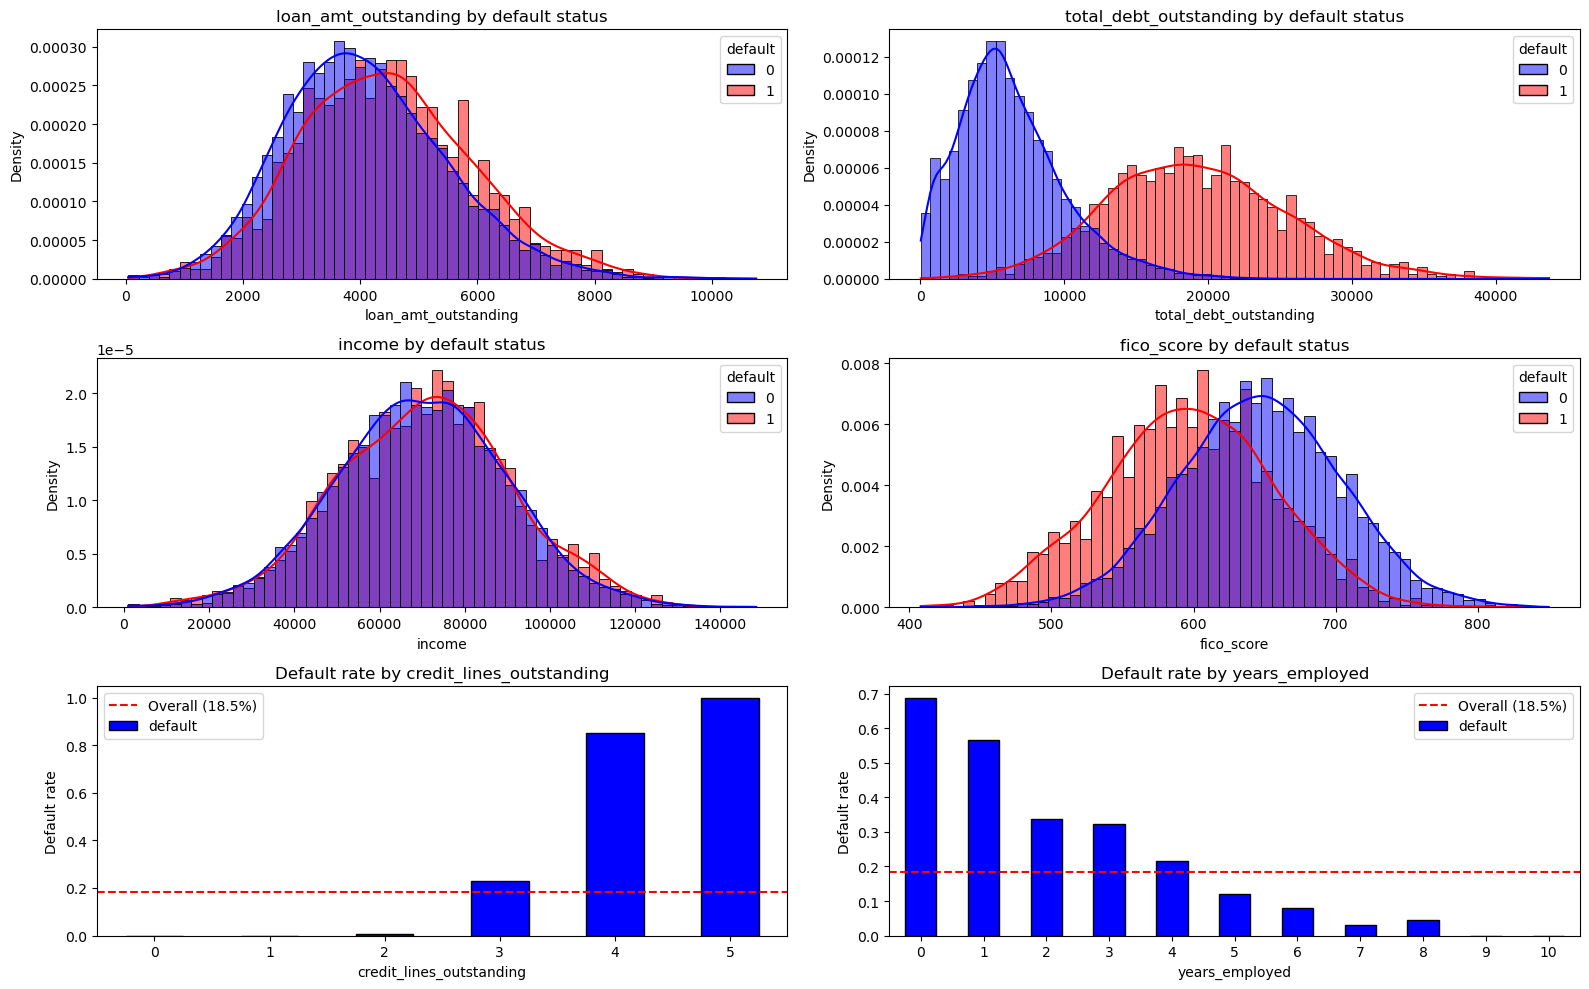

In [6]:
# EDA plots
features = loan_df.drop('default', axis = 1).columns

discrete_features = ['credit_lines_outstanding', 'years_employed']
continuous_features = features.drop(discrete_features).tolist()


fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

# Continuous:
for i, feat in enumerate(continuous_features):
    sns.histplot(data=loan_df, x=feat, hue='default', kde=True,
               stat='density', common_norm=False, ax=axes[i],
               palette={0: 'blue', 1:'red'}, alpha=0.5)
    axes[i].set_title(f"{feat} by default status")
    
# Discrete:
for j, feat in enumerate(discrete_features):
    ax_idx = len(continuous_features) + j
    default_rate = loan_df.groupby(feat)['default'].mean()
    default_rate.plot(kind='bar', ax=axes[ax_idx], color='blue', edgecolor='black', rot=0)
    axes[ax_idx].set_title(f'Default rate by {feat}')
    axes[ax_idx].set_ylabel('Default rate')
    axes[ax_idx].axhline(y=loan_df['default'].mean(), color='red', linestyle='--',
                          label=f'Overall ({loan_df["default"].mean():.1%})')
    axes[ax_idx].legend()

plt.tight_layout()
plt.show()

# Correlation Matrix

In [7]:
# Corr Matrix Calc
corr_matrix = loan_df.corr()
display(corr_matrix.round(2))

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.00,0.08,0.85,0.02,-0.09,-0.26,0.86
loan_amt_outstanding,0.08,1.00,0.40,0.84,-0.16,-0.03,0.10
total_debt_outstanding,0.85,0.40,1.00,0.39,-0.17,-0.23,0.76
income,0.02,0.84,0.39,1.00,0.00,-0.01,0.02
years_employed,-0.09,-0.16,-0.17,0.00,1.00,0.26,-0.28
fico_score,-0.26,-0.03,-0.23,-0.01,0.26,1.00,-0.32
default,0.86,0.10,0.76,0.02,-0.28,-0.32,1.00


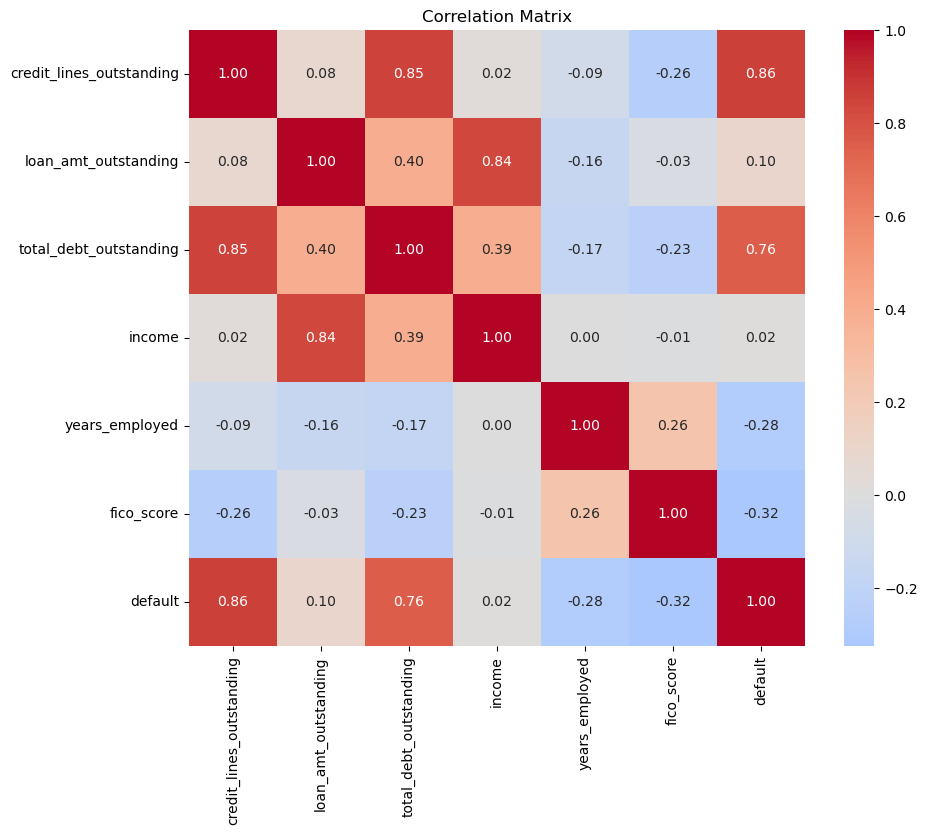

In [8]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm',
           center=0, fmt='.2f', square = True)

plt.title('Correlation Matrix')

plt.show()

In [9]:
# Extract, sorted by strength
target_corr = corr_matrix['default'].drop('default')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print(f"\n{BOLD}Correlations with default (by strength):{END}")
print(target_corr_sorted)

print(f"\n{BOLD}Actual signed correlations:{END}")
print(target_corr.loc[target_corr_sorted.index])


Correlations with default (by strength):
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
fico_score                  0.324515
years_employed              0.284506
loan_amt_outstanding        0.098978
income                      0.016309
Name: default, dtype: float64

Actual signed correlations:
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
fico_score                 -0.324515
years_employed             -0.284506
loan_amt_outstanding        0.098978
income                      0.016309
Name: default, dtype: float64


In [10]:
# Find redundant pairs
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
display(upper)

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold
]

print("\nPairs with |corr| > 0.85:")
for pair in high_corr_pairs:
    print(pair)

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,NaN,0.080249,0.852210,0.022272,-0.087900,-0.258177,0.862815
loan_amt_outstanding,NaN,NaN,0.397403,0.835815,-0.158416,-0.031373,0.098978
total_debt_outstanding,NaN,NaN,NaN,0.394397,-0.174353,-0.232246,0.758868
income,NaN,NaN,NaN,NaN,0.001814,-0.010528,0.016309
years_employed,NaN,NaN,NaN,NaN,NaN,0.255873,-0.284506
fico_score,NaN,NaN,NaN,NaN,NaN,NaN,-0.324515
default,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Pairs with |corr| > 0.85:
('total_debt_outstanding', 'credit_lines_outstanding', 0.8522099501162153)
('default', 'credit_lines_outstanding', 0.8628152536592055)


# Ratio Features

In [11]:
# Create ratio features
loan_df['debt_to_income'] = loan_df['total_debt_outstanding'] / loan_df['income']
loan_df['loan_to_income'] = loan_df['loan_amt_outstanding'] / loan_df['income']

# Quick sanity check — no infinities or NaN from division
print("Any NaN in new features?")
print(loan_df[['debt_to_income', 'loan_to_income']].isnull().sum())
print("\nAny infinities?")
print(np.isinf(loan_df[['debt_to_income', 'loan_to_income']]).sum())

# Summary stats for the new features
print("\nNew feature stats:")
print(loan_df[['debt_to_income', 'loan_to_income']].describe())

# Re-check correlation with default
new_corr = loan_df.corr()['default'].drop('default')
new_corr_sorted = new_corr.abs().sort_values(ascending=False)
print("\nUpdated correlations with default (by strength):")
print(new_corr_sorted)

print("\nSigned correlations:")
print(new_corr.loc[new_corr_sorted.index])

Any NaN in new features?
debt_to_income    0
loan_to_income    0
dtype: int64

Any infinities?
debt_to_income    0
loan_to_income    0
dtype: int64

New feature stats:
       debt_to_income  loan_to_income
count    10000.000000    10000.000000
mean         0.124018        0.059423
std          0.082802        0.010642
min          0.010000        0.012249
25%          0.068533        0.052125
50%          0.097434        0.059517
75%          0.163385        0.066717
max          0.404561        0.102103

Updated correlations with default (by strength):
credit_lines_outstanding    0.862815
debt_to_income              0.852406
total_debt_outstanding      0.758868
fico_score                  0.324515
years_employed              0.284506
loan_to_income              0.162815
loan_amt_outstanding        0.098978
income                      0.016309
Name: default, dtype: float64

Signed correlations:
credit_lines_outstanding    0.862815
debt_to_income              0.852406
total_debt_outstan

In [14]:
# Separate features from target
X = loan_df.drop(columns=['default'])
y = loan_df['default']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Verify the split
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print()
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")
print(f"Original rate:      {y.mean():.4f}")

Training set: 8000 rows
Test set:     2000 rows

Train default rate: 0.1851
Test default rate:  0.1850
Original rate:      0.1851


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from scipy.stats import ks_2samp
import pandas as pd

# 1. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fit logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 3. Predict probabilities on test set
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

# 4a. AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

# 4b. KS statistic
defaulter_scores = y_pred_proba[y_test == 1]
non_defaulter_scores = y_pred_proba[y_test == 0]
ks_stat, _ = ks_2samp(defaulter_scores, non_defaulter_scores)
print(f"KS statistic: {ks_stat:.4f}")

# 5. Confusion matrix at threshold = 0.5
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (threshold=0.5):")
print(pd.DataFrame(cm,
                   index=['Actual: No Default', 'Actual: Default'],
                   columns=['Pred: No Default', 'Pred: Default']))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# 6. Examine coefficients (which features matter most?)
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print("\nFeature coefficients (sorted by absolute magnitude):")
print(coef_df)

AUC-ROC: 1.0000
KS statistic: 0.9982

Confusion Matrix (threshold=0.5):
                    Pred: No Default  Pred: Default
Actual: No Default              1629              1
Actual: Default                    3            367

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1630
     Default       1.00      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Feature coefficients (sorted by absolute magnitude):
                    feature  coefficient
0  credit_lines_outstanding     8.007474
6            debt_to_income     3.684272
4            years_employed    -2.851407
2    total_debt_outstanding     2.263348
5                fico_score    -1.307185
3                    income    -1.106063
7            loan_to_income     0.279092
1      loan_amt_outstanding    -0.20075

In [18]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np

# Helper function so we don't repeat ourselves
def evaluate_model(name, model, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    ks_stat, _ = ks_2samp(
        y_pred_proba[y_test == 1],
        y_pred_proba[y_test == 0]
    )
    cm = confusion_matrix(y_test, y_pred)
    return {
        'name': name,
        'AUC': auc,
        'KS': ks_stat,
        'confusion_matrix': cm,
        'y_pred_proba': y_pred_proba
    }

# 1. Random Forest (no scaling needed)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf, X_test, y_test)

# 2. XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)
xgb_results = evaluate_model('XGBoost', xgb, X_test, y_test)

# 3. Comparison table
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC': 1.0000, 'KS': 0.9982},
    {'Model': 'Random Forest',       'AUC': rf_results['AUC'],  'KS': rf_results['KS']},
    {'Model': 'XGBoost',             'AUC': xgb_results['AUC'], 'KS': xgb_results['KS']},
])
print(comparison.round(4))

# 4. Confusion matrices
for r in [rf_results, xgb_results]:
    print(f"\n{r['name']} Confusion Matrix (threshold=0.5):")
    print(pd.DataFrame(
        r['confusion_matrix'],
        index=['Actual: No Default', 'Actual: Default'],
        columns=['Pred: No Default', 'Pred: Default']
    ))

# 5. Feature importances
print("\n" + "=" * 50)
print("FEATURE IMPORTANCES")
print("=" * 50)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'rf_importance':  rf.feature_importances_,
    'xgb_importance': xgb.feature_importances_
}).sort_values('xgb_importance', ascending=False)
print(importance_df.round(4))

C:\Users\Owner\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:04:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MODEL COMPARISON
                 Model     AUC      KS
0  Logistic Regression  1.0000  0.9982
1        Random Forest  0.9992  0.9745
2              XGBoost  1.0000  0.9963

Random Forest Confusion Matrix (threshold=0.5):
                    Pred: No Default  Pred: Default
Actual: No Default              1605             25
Actual: Default                    4            366

XGBoost Confusion Matrix (threshold=0.5):
                    Pred: No Default  Pred: Default
Actual: No Default              1626              4
Actual: Default                    5            365

FEATURE IMPORTANCES
                    feature  rf_importance  xgb_importance
6            debt_to_income         0.3591          0.9237
0  credit_lines_outstanding         0.3480          0.0294
4            years_employed         0.0230          0.0162
5                fico_score         0.0293          0.0141
1      loan_amt_outstanding         0.0046          0.0078
7            loan_to_income         0.0064      

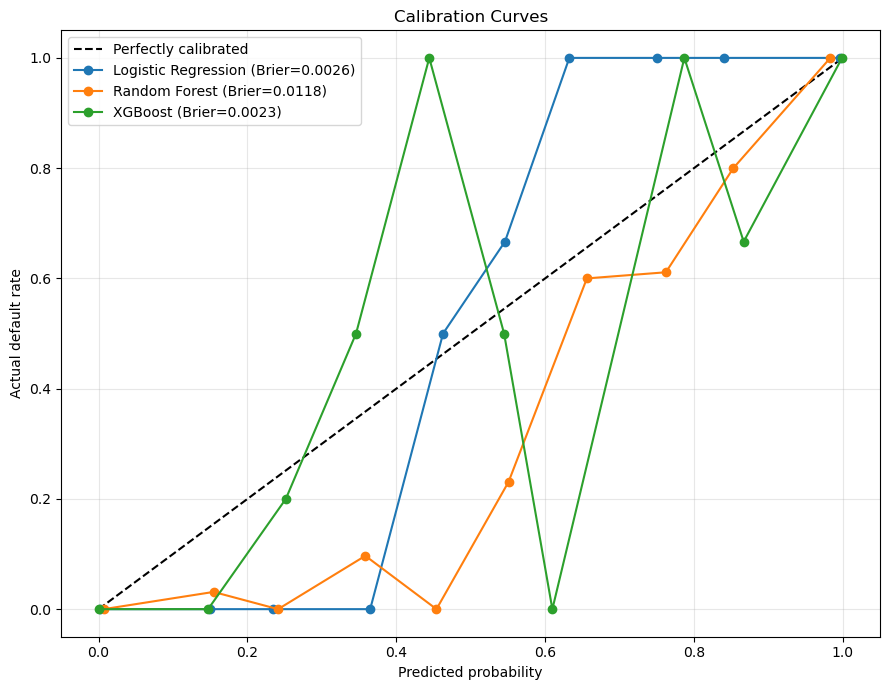

Brier Scores (lower = better):
  Logistic Regression      : 0.0026
  Random Forest            : 0.0118
  XGBoost                  : 0.0023


C:\Users\Owner\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Owner\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Owner\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Owner\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr


XGBoost (calibrated) Brier: 0.0024


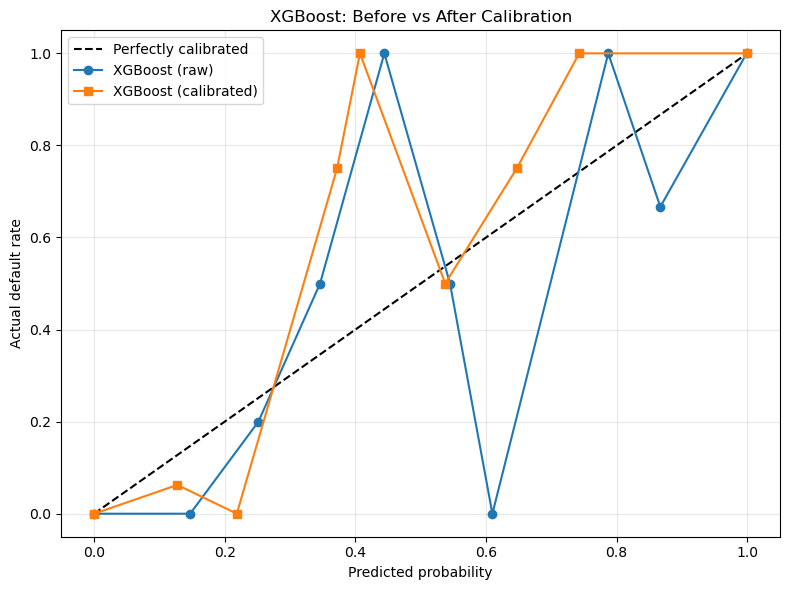

In [19]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Collect probabilities from each model
models_probs = {
    'Logistic Regression': log_reg.predict_proba(X_test_scaled)[:, 1],
    'Random Forest':       rf.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb.predict_proba(X_test)[:, 1],
}

# 1. Plot calibration curves
plt.figure(figsize=(9, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

for name, probs in models_probs.items():
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    brier = brier_score_loss(y_test, probs)
    plt.plot(prob_pred, prob_true, marker='o',
             label=f'{name} (Brier={brier:.4f})')

plt.xlabel('Predicted probability')
plt.ylabel('Actual default rate')
plt.title('Calibration Curves')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Brier scores summary
print("Brier Scores (lower = better):")
for name, probs in models_probs.items():
    print(f"  {name:25s}: {brier_score_loss(y_test, probs):.4f}")

# 3. If needed, recalibrate the worst model (commonly XGBoost or RF)
# Wrap with isotonic regression and re-evaluate
calibrated_xgb = CalibratedClassifierCV(xgb, method='isotonic', cv=5)
calibrated_xgb.fit(X_train, y_train)
cal_probs = calibrated_xgb.predict_proba(X_test)[:, 1]

print(f"\nXGBoost (calibrated) Brier: {brier_score_loss(y_test, cal_probs):.4f}")

# 4. Plot before vs after for the recalibrated model
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

prob_true, prob_pred = calibration_curve(y_test, models_probs['XGBoost'], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (raw)')

prob_true_c, prob_pred_c = calibration_curve(y_test, cal_probs, n_bins=10)
plt.plot(prob_pred_c, prob_true_c, marker='s', label='XGBoost (calibrated)')

plt.xlabel('Predicted probability')
plt.ylabel('Actual default rate')
plt.title('XGBoost: Before vs After Calibration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.stats import ks_2samp

# 1. Collect predictions from all candidate models
all_models = {
    'Logistic Regression':   (log_reg, X_test_scaled),
    'Random Forest':         (rf, X_test),
    'XGBoost':               (xgb, X_test),
    'XGBoost (calibrated)':  (calibrated_xgb, X_test),
}

# 2. Build comparison table
def get_metrics(model, X):
    y_proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    ks, _ = ks_2samp(y_proba[y_test == 1], y_proba[y_test == 0])
    brier = brier_score_loss(y_test, y_proba)
    return auc, ks, brier

results = []
for name, (model, X) in all_models.items():
    auc, ks, brier = get_metrics(model, X)
    results.append({'Model': name, 'AUC': auc, 'KS': ks, 'Brier': brier})

comparison = pd.DataFrame(results)
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(comparison.round(4).to_string(index=False))

# 3. Rank: highest AUC, then highest KS, then lowest Brier
comparison_ranked = comparison.sort_values(
    by=['AUC', 'KS', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\nRanked (best → worst):")
print(comparison_ranked.round(4).to_string(index=False))

# 4. Make the call
print("\n" + "=" * 60)
print("DECISION")
print("=" * 60)

FINAL MODEL COMPARISON
               Model    AUC     KS  Brier
 Logistic Regression 1.0000 0.9982 0.0026
       Random Forest 0.9992 0.9745 0.0118
             XGBoost 1.0000 0.9963 0.0023
XGBoost (calibrated) 0.9999 0.9955 0.0024

Ranked (best → worst):
               Model    AUC     KS  Brier
 Logistic Regression 1.0000 0.9982 0.0026
             XGBoost 1.0000 0.9963 0.0023
XGBoost (calibrated) 0.9999 0.9955 0.0024
       Random Forest 0.9992 0.9745 0.0118

DECISION


Given near-identical discrimination across all models (the dataset is 
synthetic with near-deterministic rules), the deciding factors are:

  1. Interpretability — regulators and risk teams must be able to audit 
     why a borrower was rejected.
  2. Calibration — needed for accurate Expected Loss computation.
  3. Simplicity — easier to maintain, monitor, and explain.

Logistic Regression wins on all three:
  - Coefficients are signed and directly interpretable
  - Naturally well-calibrated (optimizes log-loss directly)
  - Simplest model with comparable performance

Selected model: Logistic Regression

In [22]:
import numpy as np
import pandas as pd

# Constants from the task
RECOVERY_RATE = 0.10
LGD = 1 - RECOVERY_RATE   # 0.90

# Required input fields
REQUIRED_FIELDS = [
    'credit_lines_outstanding',
    'loan_amt_outstanding',
    'total_debt_outstanding',
    'income',
    'years_employed',
    'fico_score'
]


def expected_loss(borrower, model=log_reg, scaler=scaler, 
                  feature_order=list(X_train.columns)):
    """
    Compute expected loss for a borrower (or batch of borrowers).
    
    Parameters
    ----------
    borrower : dict or pd.DataFrame
        Borrower features. If dict, single borrower. If DataFrame, batch.
    model : trained classifier with predict_proba
    scaler : fitted StandardScaler (or None if model doesn't need scaling)
    feature_order : list of column names in the order the model was trained on
    
    Returns
    -------
    dict (single borrower) or pd.DataFrame (batch) with PD, LGD, EAD, EL
    """
    # 1. Convert input to DataFrame
    if isinstance(borrower, dict):
        df_input = pd.DataFrame([borrower])
        single = True
    else:
        df_input = borrower.copy()
        single = False
    
    # 2. Validate required fields
    missing = [f for f in REQUIRED_FIELDS if f not in df_input.columns]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    
    # 3. Replicate feature engineering from training
    df_input['debt_to_income'] = df_input['total_debt_outstanding'] / df_input['income']
    df_input['loan_to_income'] = df_input['loan_amt_outstanding'] / df_input['income']
    
    # 4. Reorder columns to match training
    X_input = df_input[feature_order]
    
    # 5. Scale (if scaler provided — needed for LR, not for trees)
    if scaler is not None:
        X_input_scaled = scaler.transform(X_input)
    else:
        X_input_scaled = X_input
    
    # 6. Predict PD
    pd_values = model.predict_proba(X_input_scaled)[:, 1]
    
    # 7. EAD = the loan amount we're exposed to
    ead_values = df_input['loan_amt_outstanding'].values
    
    # 8. Compute EL
    el_values = pd_values * LGD * ead_values
    
    # 9. Return results
    result = pd.DataFrame({
        'PD': pd_values,
        'LGD': LGD,
        'EAD': ead_values,
        'Expected_Loss': el_values
    })
    
    if single:
        return result.iloc[0].to_dict()
    return result


# ---------- Test on a few borrowers ----------

# Low-risk borrower
low_risk = {
    'credit_lines_outstanding': 0,
    'loan_amt_outstanding': 5000,
    'total_debt_outstanding': 3000,
    'income': 60000,
    'years_employed': 5,
    'fico_score': 700
}

# High-risk borrower
high_risk = {
    'credit_lines_outstanding': 5,
    'loan_amt_outstanding': 8000,
    'total_debt_outstanding': 25000,
    'income': 30000,
    'years_employed': 1,
    'fico_score': 520
}

print("LOW-RISK BORROWER")
print("-" * 40)
for k, v in expected_loss(low_risk).items():
    if k in ('PD', 'LGD'):
        print(f"  {k:15s}: {v:.4f}")
    else:
        print(f"  {k:15s}: ${v:,.2f}")

print("\nHIGH-RISK BORROWER")
print("-" * 40)
for k, v in expected_loss(high_risk).items():
    if k in ('PD', 'LGD'):
        print(f"  {k:15s}: {v:.4f}")
    else:
        print(f"  {k:15s}: ${v:,.2f}")

# ---------- Batch scoring on the test set ----------
batch_results = expected_loss(X_test)   # X_test is already a DataFrame
print("\nBATCH RESULTS (first 5 rows of test set):")
print(batch_results.head().round(4))

print(f"\nTotal expected loss on test set: ${batch_results['Expected_Loss'].sum():,.2f}")
print(f"Mean expected loss per borrower: ${batch_results['Expected_Loss'].mean():,.2f}")

LOW-RISK BORROWER
----------------------------------------
  PD             : 0.0000
  LGD            : 0.9000
  EAD            : $5,000.00
  Expected_Loss  : $0.00

HIGH-RISK BORROWER
----------------------------------------
  PD             : 1.0000
  LGD            : 0.9000
  EAD            : $8,000.00
  Expected_Loss  : $7,200.00

BATCH RESULTS (first 5 rows of test set):
    PD  LGD        EAD  Expected_Loss
0  0.0  0.9  3751.6589         0.0000
1  0.0  0.9  4377.2678         0.1752
2  0.0  0.9  4921.8222         0.0000
3  0.0  0.9  3606.4497         0.0000
4  0.0  0.9  2441.0355         0.0000

Total expected loss on test set: $1,493,132.13
Mean expected loss per borrower: $746.57


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import numpy as np
import pandas as pd

# Read in loan data from a CSV file
df = pd.read_csv('loan_data.csv')

# Define the variable features
features = ['credit_lines_outstanding', 'debt_to_income', 'payment_to_income', 'years_employed', 'fico_score']

# Calculate the payment_to_income ratio
df['payment_to_income'] = df['loan_amt_outstanding'] / df['income']
    
# Calculate the debt_to_income ratio
df['debt_to_income'] = df['total_debt_outstanding'] / df['income']

clf = LogisticRegression(random_state=0, solver='liblinear', tol=1e-5, max_iter=10000).fit(df[features], df['default'])
print(clf.coef_, clf.intercept_)

# Use the following code to check yourself
y_pred = clf.predict(df[features])

fpr, tpr, thresholds = metrics.roc_curve(df['default'], y_pred)
print((1.0*(abs(df['default']-y_pred)).sum()) / len(df))
print(metrics.auc(fpr, tpr))


[[ 8.18520373  0.54490854  0.01994244 -2.77630853 -0.02418391]] [-0.09162643]
0.0037
0.9925106069101026
